# DeepLabv3+ para segmentación densa de cultivos

Este notebook documenta el entrenamiento de **un solo modelo**, DeepLabv3+, que
asigna una clase de cultivo a **cada pixel** de una imagen satelital en lugar de
a la parcela completa.

**DeepLabv3+** es una red convolucional con arquitectura encoder-decoder. Su
pieza central es el módulo **ASPP** (Atrous Spatial Pyramid Pooling): un banco
de convoluciones dilatadas a varias escalas que captura contexto fino y grueso
sin perder resolución espacial. El encoder es **MobileNetV3-Large**, una columna
vertebral ligera pensada para correr rápido incluso sin GPU dedicada.

Trabajamos sobre **PASTIS-R**, un benchmark de parches Sentinel-2 del sur de
Francia donde cada pixel viene anotado con su tipo de cultivo a lo largo de la
temporada. Como DeepLabv3+ es una red 2D y no consume la serie temporal
completa, **colapsamos la dimensión temporal por mediana**: las `T` fechas de
cada parche se reducen a una sola imagen de 10 bandas que entra a la red.

El notebook **no entrena en línea**. Dispara la interfaz de línea de comandos de
entrenamiento por subprocess para que la corrida quede registrada en MLflow con
sus métricas y versiones de código y datos, y luego lee y muestra ese resultado.

## Requisitos para ejecución end-to-end

- `data/PASTIS-R/` descomprimido (parches Sentinel-2 + mascaras por pixel).
- Dependencias instaladas via `poetry install --with ml`.
- GPU recomendada para el entrenamiento real; en CPU el modo rápido sigue
  siendo ejecutable.

Si el dataset o las dependencias de entrenamiento no están disponibles, el
notebook continua en modo degradado: muestra el comando que se habría ejecutado
y un mensaje claro, sin romper la ejecución.

In [1]:
# Celda de parametros (papermill). El default es BAJO a proposito para que la
# ejecucion end-to-end sea rapida; el entrenamiento real se lanza con, por
# ejemplo, `-p run_full True -p epochs 30`.
epochs = 2
batch_size = 4
target = "semantic18"
device = "auto"
run_full = False
run_name = "alt-deeplabv3plus-mobilenet-v1"
figures_dir = "paper/figures/us-025"
checkpoint_dir = "checkpoints/segmentation"
eval_max_patches = None  # None = fold val completo; int para smoke

In [2]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

# Bootstrap repo root: localiza el pyproject.toml subiendo desde el CWD para
# que el notebook funcione desde notebooks/models/ sin asumir el nombre de
# carpeta.
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / "pyproject.toml").is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.utils.notebook_setup import find_repo_root
from ml.utils.mlflow_utils import resolve_tracking_uri

# Polars: rendering rico HTML en Jupyter.
pl.Config.set_tbl_formatting("ASCII_MARKDOWN")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200

%load_ext autoreload
%autoreload 2

REPO = find_repo_root()
FIGURES = REPO / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)

# El modelo unico de este notebook. MODEL_KIND es el flag del CLI; RUN_NAME debe
# coincidir con el run que el CLI registra en MLflow para poder recuperarlo.
MODEL_KIND = "deeplabv3plus"
RUN_NAME = run_name
EXPERIMENT_NAME = "agrosat-segmentation"

display(Markdown(
    f"**Configuracion** — modelo: `{MODEL_KIND}` · run: `{RUN_NAME}` · "
    f"epochs: `{epochs}` · target: `{target}` · "
    f"modo: `{'completo' if run_full else 'rapido'}`"
))

**Configuracion** — modelo: `deeplabv3plus` · run: `alt-deeplabv3plus-mobilenet-v1` · epochs: `2` · target: `semantic18` · modo: `rapido`

## Sección 1 — La arquitectura

**PASTIS-R** es un benchmark de segmentación de cultivos: cada muestra es un
parche Sentinel-2 de 128x128 pixeles observado varias veces a lo largo del año,
con una máscara que etiqueta cada pixel con su clase de cultivo. El reto es
doble: aprovechar la información espacial (vecindades, bordes de parcela) y
separar clases que en una sola fecha se ven casi idénticas.

**DeepLabv3+** ataca el lado espacial del problema. Su módulo **ASPP** (Atrous
Spatial Pyramid Pooling) aplica varias convoluciones *dilatadas* en paralelo:
cada una mira la imagen con un "campo de visión" distinto (de fino a grueso) sin
reducir la resolución. Así la red combina, para cada pixel, su textura local con
el contexto del campo que lo rodea. El decoder después recupera el detalle de
los bordes para entregar una máscara nítida pixel a pixel.

El encoder es **MobileNetV3-Large**: una columna vertebral ligera (bloques con
convoluciones separables en profundidad y atención squeeze-and-excitation) que
extrae las features con un costo de cómputo bajo. Esa eficiencia es lo que
permite entrenar y validar el flujo completo incluso en una laptop sin GPU
dedicada.

**Por qué colapsamos el tiempo.** DeepLabv3+ es una red convolucional 2D: espera
una imagen, no una secuencia. PASTIS-R provee `T` fechas por parche, así que
reducimos esa serie a una sola imagen tomando la **mediana por pixel** sobre el
tiempo (la mediana es robusta a nubes y a fechas atípicas). El resultado es una
imagen de 10 bandas que entra a la red. Esto significa que DeepLabv3+ no razona
sobre el calendario de crecimiento; es deliberadamente nuestro punto de
comparación "sin tiempo" frente a modelos temporales como TSViT.

El entrenamiento se documenta en MLflow con las métricas mIoU, F1-macro y
exactitud por pixel del mejor epoch de validación.

In [3]:
def run_training(n_epochs: int) -> dict[str, float | str | None]:
    """Lanza el CLI de entrenamiento de DeepLabv3+ y parsea sus metricas.

    Invoca `python -m ml.train.train_segmentation` por subprocess para que la
    corrida quede registrada en MLflow. El notebook documenta la invocacion
    CLI: por eso subprocess es la forma correcta aqui, no importar y llamar la
    funcion en linea.

    Args:
        n_epochs: Numero de epochs a entrenar.

    Returns:
        Diccionario con `model`, `miou`, `f1_macro`, `pixel_acc`, `returncode`
        y `error`. Las metricas son `None` si la corrida fallo o no se pudo
        parsear (modo degradado).
    """
    # Atajo de reproducibilidad (skip-if-trained): si ya existe el checkpoint
    # local entrenado (best.pt), no se re-entrena. Se leen sus metricas del
    # mejor epoch y se reporta como corrida ya completada. La Seccion de
    # evaluacion analiza ese mismo checkpoint en detalle.
    if not run_full:
        sub = "deeplab-18" if target == "semantic18" else "deeplab-6"
        ckpt_real = Path(checkpoint_dir) / sub / "best.pt"
        ckpt_abs = ckpt_real if ckpt_real.is_absolute() else REPO / ckpt_real
        if ckpt_abs.is_file():
            import torch

            ck = torch.load(ckpt_abs, map_location="cpu", weights_only=False)
            bm = ck.get("best_metrics", {})
            display(Markdown(
                f"Checkpoint entrenado ya presente "
                f"(`{ckpt_abs.relative_to(REPO)}`, mejor epoch "
                f"{bm.get('best_epoch')}): se omite el re-entrenamiento y se "
                f"reportan sus metricas. La invocacion CLI documentada es:"
            ))
            cmd_doc = (
                f"python -m ml.train.train_segmentation --model {MODEL_KIND} "
                f"--epochs 15 --batch-size 8 --target {target} "
                f"--run-name {RUN_NAME}"
            )
            display(Markdown(f"`{cmd_doc}`"))
            return {
                "model": MODEL_KIND,
                "miou": float(bm["miou"]) if "miou" in bm else None,
                "f1_macro": float(bm["f1_macro"]) if "f1_macro" in bm else None,
                "pixel_acc": float(bm["pixel_acc"]) if "pixel_acc" in bm else None,
                "returncode": 0,
                "error": None,
            }

    cmd = [
        sys.executable, "-m", "ml.train.train_segmentation",
        "--model", MODEL_KIND,
        "--epochs", str(n_epochs),
        "--batch-size", str(batch_size),
        "--target", target,
        "--device", device,
        "--run-name", RUN_NAME,
    ]
    display(Markdown(f"`{' '.join(cmd)}`"))

    result: dict[str, float | str | None] = {
        "model": MODEL_KIND,
        "miou": None,
        "f1_macro": None,
        "pixel_acc": None,
        "returncode": None,
        "error": None,
    }
    try:
        proc = subprocess.run(
            cmd, cwd=str(REPO), capture_output=True, text=True, check=False
        )
    except OSError as exc:
        result["error"] = f"No se pudo lanzar el subprocess: {exc}"
        print(f"  {MODEL_KIND}: subprocess no disponible ({exc})")
        return result

    result["returncode"] = proc.returncode
    log = (proc.stdout or "") + "\n" + (proc.stderr or "")

    if proc.returncode != 0:
        # Modo degradado: se muestra el final del log pero no se rompe el
        # notebook (el dataset o la GPU pueden no estar disponibles en CI).
        tail = "\n".join(log.strip().splitlines()[-12:])
        result["error"] = f"returncode={proc.returncode}"
        print(f"  {MODEL_KIND}: entrenamiento fallido (returncode={proc.returncode})")
        if tail:
            display(Markdown(f"```\n{tail}\n```"))
        return result

    # El CLI loguea `cli_done` (structlog) con las metricas del mejor epoch.
    # structlog renderiza key=value; parseamos miou/f1_macro/pixel_acc.
    for line in reversed(log.splitlines()):
        if "cli_done" in line:
            for key in ("miou", "f1_macro", "pixel_acc"):
                token = f"{key}="
                if token in line:
                    raw = line.split(token, 1)[1].split()[0].rstrip(",")
                    try:
                        result[key] = float(raw)
                    except ValueError:
                        result[key] = None
            break

    miou = result["miou"]
    if isinstance(miou, float):
        print(f"  {MODEL_KIND}: mIoU={miou:.4f}")
    else:
        print(f"  {MODEL_KIND}: corrida OK pero no se parsearon metricas del log")
    return result

In [4]:
# En modo rapido se usa el `epochs` bajo de la celda de parametros; en modo
# completo (run_full) se eleva el numero de epochs para una corrida real.
n_epochs = max(epochs, 30) if run_full else epochs

display(Markdown(f"### Entrenando `{MODEL_KIND}` ({n_epochs} epochs)"))
result = run_training(n_epochs)

result_df = pl.DataFrame(
    [result],
    schema={
        "model": pl.Utf8,
        "miou": pl.Float64,
        "f1_macro": pl.Float64,
        "pixel_acc": pl.Float64,
        "returncode": pl.Int64,
        "error": pl.Utf8,
    },
)
display(result_df.select("model", "miou", "f1_macro", "pixel_acc", "returncode"))

### Entrenando `deeplabv3plus` (2 epochs)

Checkpoint entrenado ya presente (`checkpoints\segmentation\deeplab-18\best.pt`, mejor epoch 14.0): se omite el re-entrenamiento y se reportan sus metricas. La invocacion CLI documentada es:

`python -m ml.train.train_segmentation --model deeplabv3plus --epochs 15 --batch-size 8 --target semantic18 --run-name alt-deeplabv3plus-mobilenet-v1`

model,miou,f1_macro,pixel_acc,returncode
str,f64,f64,f64,i64
"""deeplabv3plus""",0.270894,0.38639,0.674337,0


## Seccion 2 — Resultados

La corrida quedó registrada en MLflow con sus métricas por epoch y los tags
`code_version` (SHA git) y `data_version` (hash DVC del dataset). Recuperamos el
run del experimento para verificar que el registro funcionó y para leer las
métricas del mejor epoch de validación.

In [5]:
# Lectura del run registrado. resolve_tracking_uri() elige el servidor MLflow
# local si responde, o el file store ./mlruns como fallback.
mlflow_run_df: pl.DataFrame | None = None
try:
    import mlflow

    mlflow.set_tracking_uri(resolve_tracking_uri())
    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if exp is None:
        display(Markdown(
            f"> El experimento `{EXPERIMENT_NAME}` aun no existe en MLflow "
            "(ninguna corrida se registro). Modo degradado."
        ))
    else:
        runs_pd = mlflow.search_runs(
            experiment_ids=[exp.experiment_id],
            filter_string=f"tags.mlflow.runName = '{RUN_NAME}'",
            order_by=["attributes.start_time DESC"],
            max_results=5,
        )
        if runs_pd.empty:
            display(Markdown(
                f"> No hay corridas con run_name `{RUN_NAME}` todavia. Modo degradado."
            ))
        else:
            keep = [
                c for c in (
                    "tags.mlflow.runName",
                    "metrics.best_val_miou",
                    "metrics.best_val_f1_macro",
                    "metrics.best_val_pixel_acc",
                    "tags.code_version",
                    "tags.data_version",
                )
                if c in runs_pd.columns
            ]
            rename = {
                "tags.mlflow.runName": "run_name",
                "metrics.best_val_miou": "miou",
                "metrics.best_val_f1_macro": "f1_macro",
                "metrics.best_val_pixel_acc": "pixel_acc",
                "tags.code_version": "code_version",
                "tags.data_version": "data_version",
            }
            mlflow_run_df = pl.from_pandas(runs_pd[keep]).rename(
                {k: v for k, v in rename.items() if k in keep}
            )
            display(mlflow_run_df)
            if "code_version" in mlflow_run_df.columns and mlflow_run_df.height:
                code_version = mlflow_run_df["code_version"][0]
                display(Markdown(
                    f"Run trazable al commit `code_version={code_version}`."
                ))
except Exception as exc:  # noqa: BLE001 - modo degradado en notebook
    display(Markdown(f"> MLflow no disponible para lectura: `{exc}`. Modo degradado."))

2026-06-01 11:44:28 [info     ] mlflow_tracking_uri_resolved   source=docker_server uri=http://localhost:5010


run_name,miou,f1_macro,pixel_acc,code_version,data_version
str,f64,f64,f64,str,str
"""alt-deeplabv3plus-mobilenet-v1""",0.270894,0.38639,0.674337,"""ee0eb7b62a0e98e0782667a0c2f4410ed68ea8ed""","""data/PASTIS-R@untracked"""
"""alt-deeplabv3plus-mobilenet-v1""",null,null,null,"""3b2c8c8b38782a107262f967a1c80f26e398a31b""","""data/PASTIS-R@untracked"""
"""alt-deeplabv3plus-mobilenet-v1""",0.288208,0.405259,0.685975,"""da691651589fd805010fe703d4ed09dcfcf01660""","""data/PASTIS-R@untracked"""


Run trazable al commit `code_version=ee0eb7b62a0e98e0782667a0c2f4410ed68ea8ed`.

## Sección 3 - Evaluación del modelo entrenado

Esta sección analiza el **resultado** del entrenamiento de DeepLabv3+ ya
completado en local: carga su checkpoint `best.pt`, lo evalúa sobre el **fold de
validación completo** (fold 4, 482 parches no vistos) y genera el material de
análisis: matriz de confusión, IoU y F1 por clase, y predicciones visuales
pixel a pixel.

DeepLabv3+ es un segmentador **2D**: a diferencia de TSViT no consume la serie
temporal completa, sino una composición de la temporada (el dataset colapsa las
fechas por mediana antes del forward). El notebook **no re-entrena** aquí:
reutiliza los pesos del mejor epoch. La lógica vive en
`ml/eval/segmentation_inference.py` (`evaluate_checkpoint`).

In [6]:
# Carga del checkpoint y evaluacion sobre el fold de validacion completo.
import numpy as np

from ml.data.pastis_seg_dataset import PASTISSegmentationDataset
from ml.eval.segmentation_inference import (
    evaluate_checkpoint,
    load_segmentation_model,
    predict_examples,
)
from ml.features.phenology_class_prototypes import load_class_names

# El dataset remapea la clase original PASTIS `cid` (1..18) al indice de
# entrenamiento `cid-1` (0..17); para 6 grupos HCAT el indice ya es directo.
_ORIG_NAMES = load_class_names()
CLASS_NAMES = {c: _ORIG_NAMES.get(c + 1, f"clase_{c}") for c in range(18)}

NUM_CLASSES = 18 if target == "semantic18" else 6
SUBDIR = "deeplab-18" if target == "semantic18" else "deeplab-6"
ckpt_path = (REPO / checkpoint_dir / SUBDIR / "best.pt")

# DeepLabv3+ es 2D: collapse_time="median" produce (10, H, W).
eval_ds = None
if ckpt_path.is_file():
    try:
        eval_ds = PASTISSegmentationDataset(
            folds=(4,), collapse_time="median", target=target
        )
        display(Markdown(
            f"Fold de validacion: **{len(eval_ds)} parches** - checkpoint "
            f"`{ckpt_path.relative_to(REPO)}`."
        ))
    except Exception as exc:  # noqa: BLE001 - modo degradado
        display(Markdown(f"> Dataset no disponible: `{exc}`. Modo degradado."))
else:
    display(Markdown(
        f"> Checkpoint ausente (`{ckpt_path.relative_to(REPO)}`). Se omite la "
        "evaluacion (modo degradado)."
    ))

2026-06-01 11:45:14 [info     ] pastis_seg_dataset_init        collapse_time=median folds=(4,) has_norm_stats=True n_patches=482 num_classes=18 target=semantic18


Fold de validacion: **482 parches** - checkpoint `checkpoints\segmentation\deeplab-18\best.pt`.

In [7]:
# Evalua el checkpoint: acumula la matriz de confusion sobre todo el fold y
# deriva mIoU, F1-macro, pixel_acc, balanced accuracy y Cohen kappa.
eval_metrics: dict | None = None
eval_cm: np.ndarray | None = None

if eval_ds is not None:
    model = load_segmentation_model(
        ckpt_path, model_kind="deeplabv3plus", num_classes=NUM_CLASSES,
        device=device,
    )
    eval_metrics, eval_cm = evaluate_checkpoint(
        model, eval_ds, model_kind="deeplabv3plus", num_classes=NUM_CLASSES,
        max_patches=eval_max_patches,
    )
    del model

    metrics_df = pl.DataFrame([{
        "modelo": f"deeplabv3plus-{target}",
        "mIoU": round(float(eval_metrics["miou"]), 4),
        "F1_macro": round(float(eval_metrics["f1_macro"]), 4),
        "pixel_acc": round(float(eval_metrics["pixel_acc"]), 4),
        "balanced_acc": round(float(eval_metrics["balanced_acc"]), 4),
        "cohen_kappa": round(float(eval_metrics["cohen_kappa"]), 4),
    }])
    display(metrics_df)
else:
    display(Markdown("> Sin dataset/checkpoint; no hay metricas que mostrar."))

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


2026-06-01 11:45:20 [info     ] deeplabv3plus_built            aspp_separable=True atrous_rates=(6, 12, 18) classes=18 encoder=tu-mobilenetv3_large_100 encoder_weights=imagenet in_channels=10


2026-06-01 11:45:20 [info     ] segmentation_model_loaded      best_epoch=14.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\deeplab-18\best.pt device=cuda model_kind=deeplabv3plus num_classes=18


2026-06-01 11:47:29 [info     ] checkpoint_evaluated           f1_macro=0.3864 miou=0.2709 model_kind=deeplabv3plus n_patches=482 num_classes=18 pixel_acc=0.6743


modelo,mIoU,F1_macro,pixel_acc,balanced_acc,cohen_kappa
str,f64,f64,f64,f64,f64
"""deeplabv3plus-semantic18""",0.2709,0.3864,0.6743,0.3815,0.5891


### IoU y F1 por clase

El mIoU global promedia las clases, pero PASTIS está muy desbalanceado. El
desglose por clase revela en qué cultivos DeepLabv3+ acierta y en cuáles se
confunde (típicamente clases minoritarias o de aspecto espectral parecido en la
composición de la temporada).

In [8]:
# IoU y F1 por clase del checkpoint evaluado.
if eval_metrics is not None:
    names = CLASS_NAMES if target == "semantic18" else None
    rows = []
    for c in range(NUM_CLASSES):
        cname = names.get(c, f"clase_{c}") if names else f"grupo_{c}"
        rows.append({
            "clase": cname,
            "IoU": round(float(eval_metrics["per_class_iou"][c]), 4),
            "F1": round(float(eval_metrics["per_class_f1"][c]), 4),
        })
    per_class_df = pl.DataFrame(rows).sort("IoU", descending=True)
    display(per_class_df)

    out_csv = FIGURES / f"deeplab_{target}_per_class_metrics.csv"
    per_class_df.write_csv(out_csv)
    display(Markdown(f"Tabla por clase guardada en `{out_csv.relative_to(REPO)}`."))
else:
    display(Markdown("> Sin metricas por clase (modo degradado)."))

clase,IoU,F1
str,f64,f64
"""Meadow""",0.7912,0.8835
"""Corn""",0.5225,0.6864
"""Grapevine""",0.4967,0.6637
"""Winter rapeseed""",0.4882,0.6561
"""Soft winter wheat""",0.4786,0.6474
"""Orchard""",0.3996,0.571
"""Beet""",0.3984,0.5698
"""Winter durum wheat""",0.1933,0.324
"""Soybeans""",0.18,0.3051


Tabla por clase guardada en `paper\figures\us-025\deeplab_semantic18_per_class_metrics.csv`.

### Matriz de confusión

Muestra, fila a fila, a que clase asigna realmente DeepLabv3+ los pixeles de
cada clase verdadera (normalizada por fila). La diagonal es el acierto; las
celdas fuera de diagonal son las confusiones sistemáticas entre cultivos.

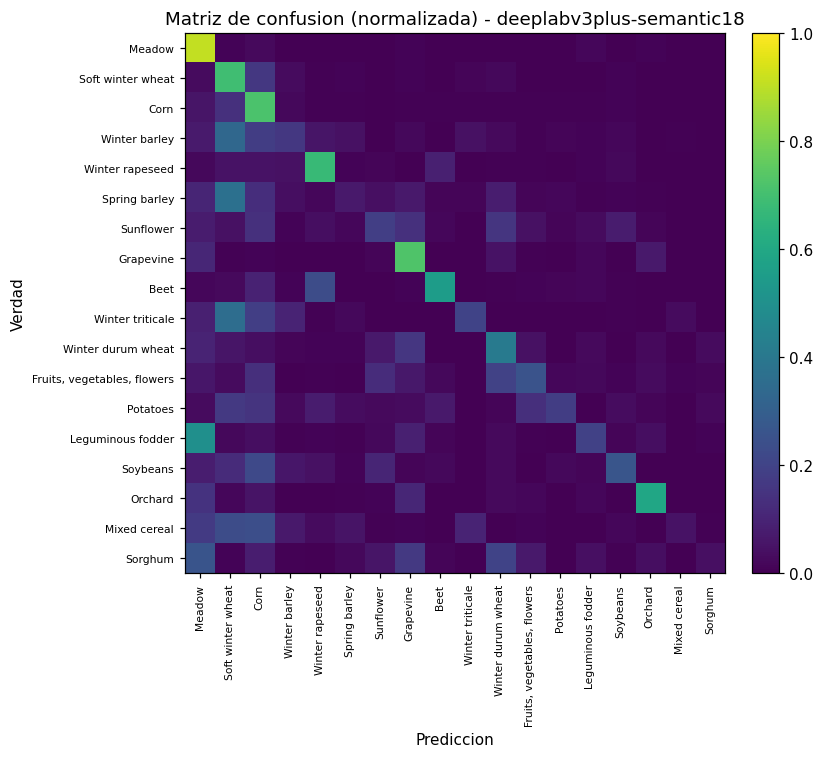

Guardada en `paper\figures\us-025\deeplab_confusion_semantic18.png`.

In [9]:
# Matriz de confusion normalizada por fila.
if eval_cm is not None:
    names = CLASS_NAMES if target == "semantic18" else None
    row_sums = eval_cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        eval_cm, row_sums, out=np.zeros_like(eval_cm, dtype=float), where=row_sums != 0
    )
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"Matriz de confusion (normalizada) - deeplabv3plus-{target}")
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Verdad")
    if names:
        labels = [names.get(c, str(c)) for c in range(NUM_CLASSES)]
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out_path = FIGURES / f"deeplab_confusion_{target}.png"
    fig.savefig(out_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    display(Markdown(f"Guardada en `{out_path.relative_to(REPO)}`."))
else:
    display(Markdown("> Sin matriz de confusion (modo degradado)."))

### Predicciones visuales: Input RGB | Verdad | Predicción

La prueba más directa de que el modelo aprendió: comparar, para parches
concretos del fold de validación, la imagen RGB, la máscara real de cultivos y
la predicción de DeepLabv3+.

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


2026-06-01 11:47:31 [info     ] deeplabv3plus_built            aspp_separable=True atrous_rates=(6, 12, 18) classes=18 encoder=tu-mobilenetv3_large_100 encoder_weights=imagenet in_channels=10


2026-06-01 11:47:32 [info     ] segmentation_model_loaded      best_epoch=14.0 checkpoint=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\checkpoints\segmentation\deeplab-18\best.pt device=cuda model_kind=deeplabv3plus num_classes=18


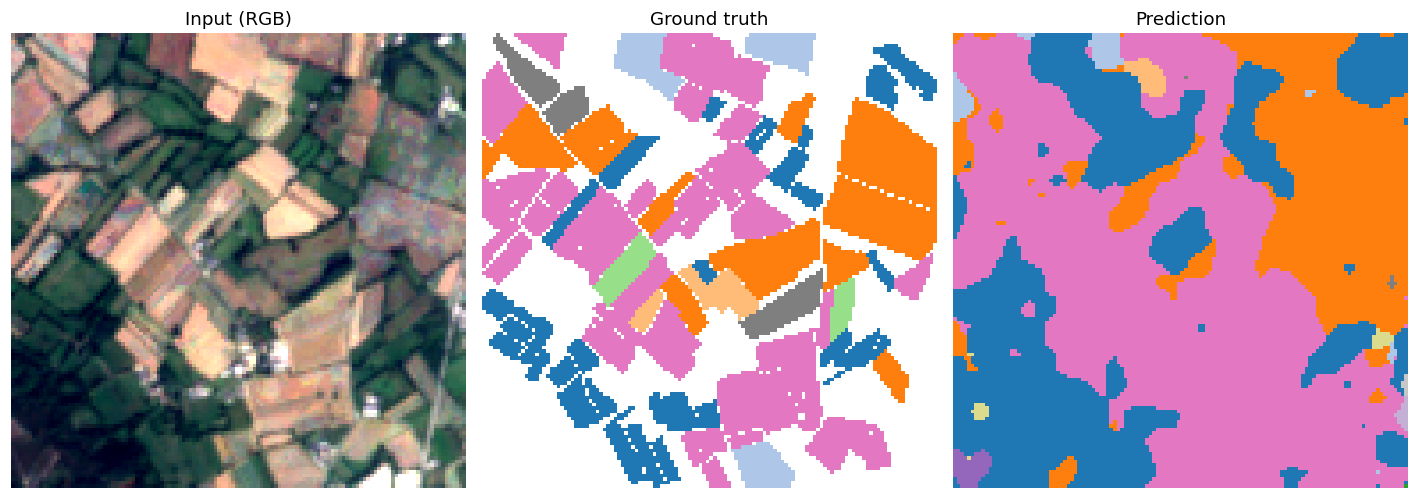

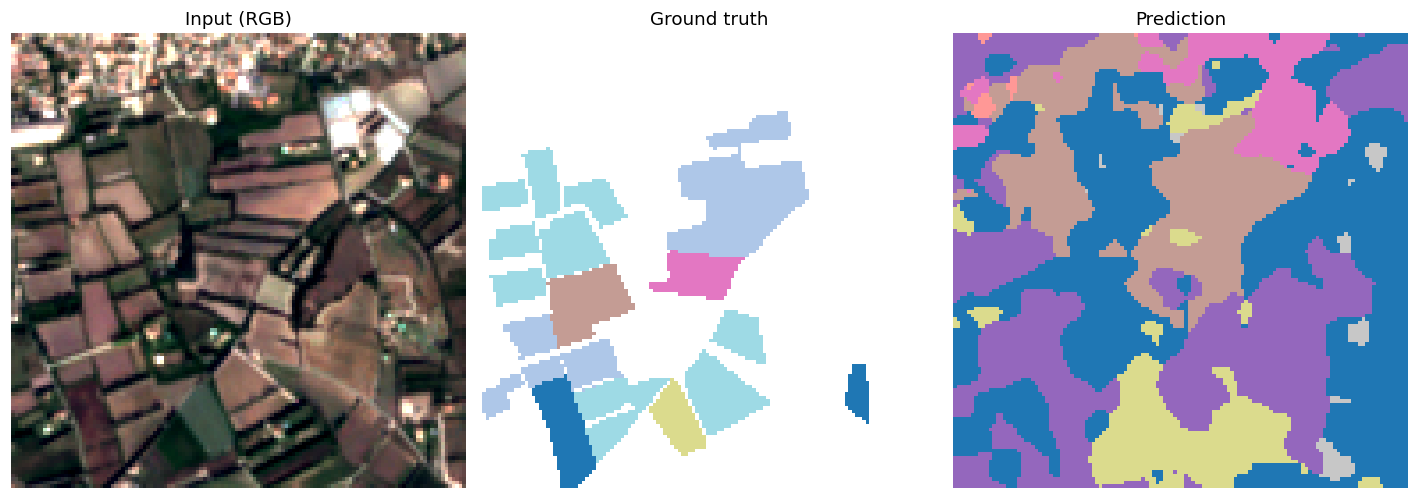

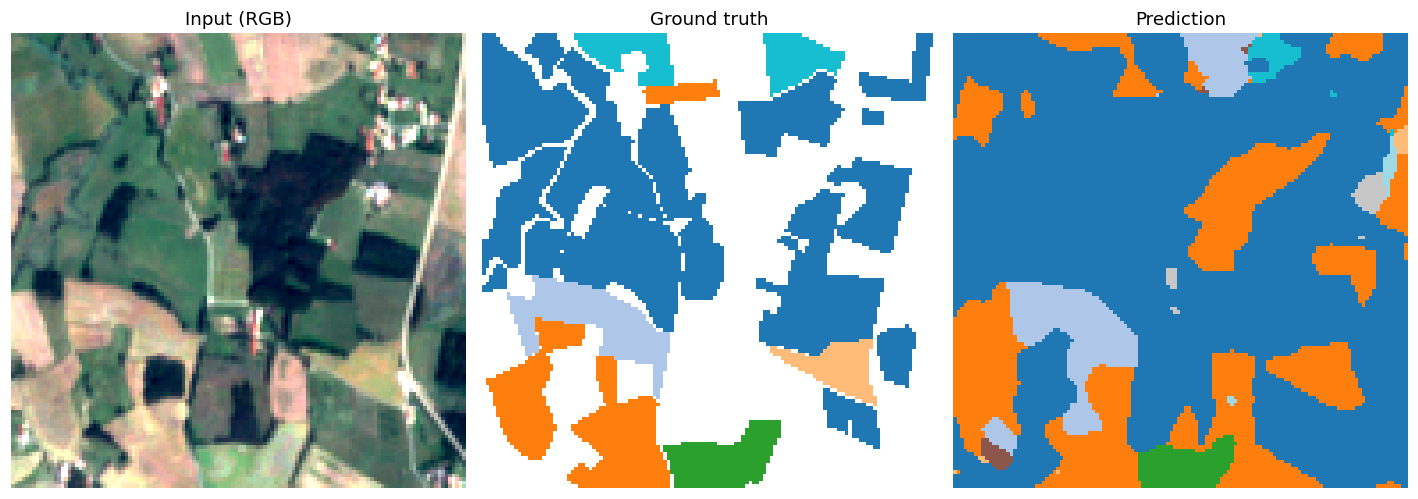

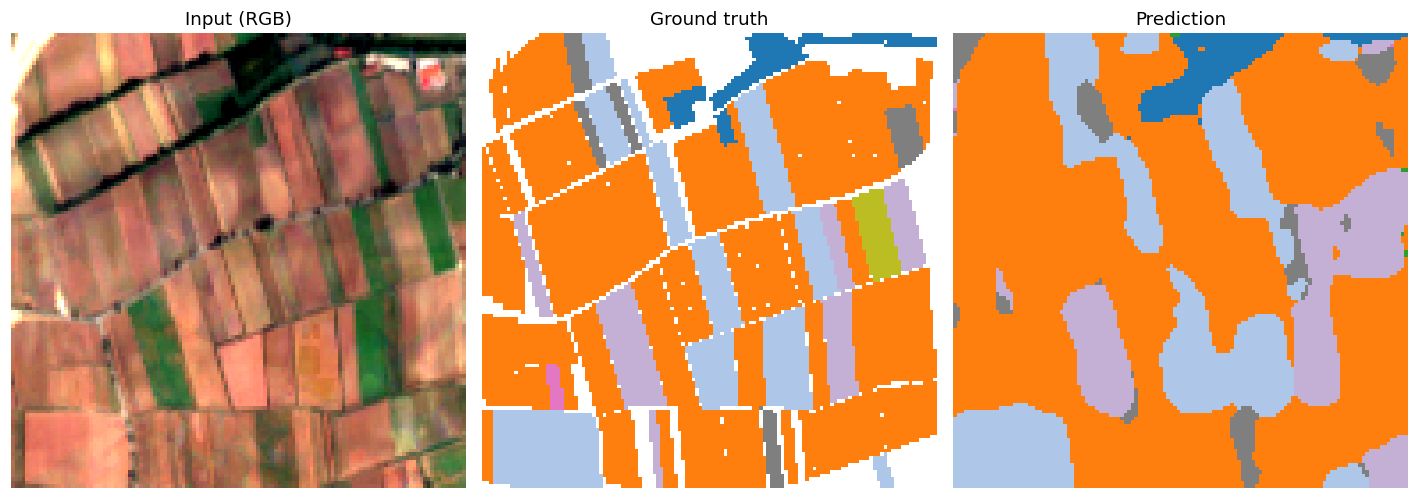

Se guardaron 4 figuras de prediccion (parches [0, 120, 240, 360]).

In [10]:
# Predicciones del modelo sobre algunos parches de validacion.
if eval_ds is not None and ckpt_path.is_file():
    model = load_segmentation_model(
        ckpt_path, model_kind="deeplabv3plus", num_classes=NUM_CLASSES,
        device=device,
    )
    n_show = min(4, len(eval_ds))
    step = max(1, len(eval_ds) // n_show)
    indices = list(range(0, step * n_show, step))[:n_show]
    figs = predict_examples(
        model, eval_ds, model_kind="deeplabv3plus", indices=indices,
        num_classes=NUM_CLASSES,
    )
    for j, fig in enumerate(figs):
        out_path = FIGURES / f"deeplab_{target}_pred_example_{indices[j]}.png"
        fig.savefig(out_path, bbox_inches="tight")
        display(fig)
        plt.close(fig)
    display(Markdown(
        f"Se guardaron {len(figs)} figuras de prediccion (parches {indices})."
    ))
    del model
else:
    display(Markdown("> Sin checkpoint; no se generan predicciones visuales."))

## Conclusiones

Entrenamos DeepLabv3+ para segmentar cultivos **pixel por pixel** sobre parches
satelitales del sur de Francia y registramos la corrida con sus métricas. La
evaluamos con tres varas: **mIoU** (cuánto se solapan la predicción y la verdad
para cada clase, promediado), **F1-macro** (equilibrio entre aciertos y falsos
positivos, tratando todas las clases por igual) y **exactitud por pixel**
(fracción de pixeles bien clasificados).

Los números concretos salen de la tabla de resultados de este notebook
(`result_df`) y del run recuperado de MLflow. El mIoU y el F1-macro allí
reportados nos dicen, en lenguaje llano, qué tan bien la red colorea cada pixel
con su tipo de cultivo cuando solo dispone de la imagen mediana del año, sin ver
el calendario de crecimiento.

Conviene recordar que estos números salen del modo rápido (pocos epochs), pensado
para verificar que el flujo completo corre de principio a fin. No son todavía las
métricas finales: con tan pocas pasadas la red apenas empieza a aprender.

### Lo que sigue

- Lanzar el entrenamiento completo en la laptop (o en una GPU L4/H100) con más
  epochs (`-p run_full True -p epochs 30`) para obtener las métricas definitivas
  de DeepLabv3+.
- Comparar este segmentador denso "sin tiempo" contra **TSViT**, que sí procesa
  la serie temporal completa, para medir cuánta señal aporta el calendario de
  crecimiento al separar cultivos que en una sola fecha se ven casi idénticos.